In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import matplotlib as mpl
import pandas as pd

In [2]:
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['lines.markersize'] = 6
mpl.rcParams['figure.autolayout'] = True
mpl.rcParams['font.size'] = 15
mpl.rcParams['errorbar.capsize'] = 3
mpl.rcParams['lines.markeredgewidth'] = 1
mpl.rcParams['axes.axisbelow'] = True

In [3]:
def transform_angles(angs): # transforma los ángulos de 0-2pi a 0-pi/2 y luego a grados, para ver lo que nos interesa
    new_angs = angs % np.pi
    new_angs = np.where(new_angs > np.pi/2, np.pi - new_angs,new_angs)
    new_angs = np.degrees(new_angs)
    return new_angs

def load_data(file):
    raw_data = np.loadtxt(f'{file}',delimiter=',')
    total_muons = raw_data[0]
    raw_angles = raw_data[1:]
    angles = transform_angles(raw_angles)
    return angles,total_muons

def calc_res_ang(det_size,det_height,det_delta):
    h = det_size
    l = det_height*2+det_delta
    res_ang = np.degrees(np.arctan(h/l))
    return res_ang

res_ang = calc_res_ang(4.0,1.1,23.6)
bins_res = np.arange(0,100,res_ang*2)

In [4]:
cos2_pdf = lambda x : np.cos(x)**2/(np.pi/4)
cos2_cdf = lambda x : (np.radians(x) + np.cos(np.radians(x))*np.sin(np.radians(x)))/(2*np.pi/4)
cos_cdf = lambda x : np.sin(np.radians(x))
def ecdf(a):
    x, counts = np.unique(a, return_counts=True)
    cusum = np.cumsum(counts)
    return x, cusum / cusum[-1]

In [5]:
from scipy.stats import kstest
from scipy.optimize import curve_fit as cf
cos_n = lambda x,A,n : A*np.cos(np.radians(x))**n
from scipy.stats import chi2

[0.02229673 2.08280268]
212824
[[0.00014342 0.0017091 ]
 [0.0017091  0.03539318]]
KstestResult(statistic=np.float64(0.005869566161297413), pvalue=np.float64(8.524037161730718e-07), statistic_location=np.float64(28.444634329709647), statistic_sign=np.int8(1))


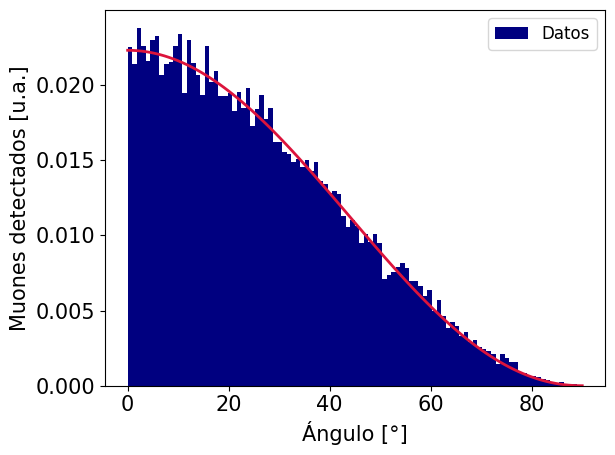

In [33]:
measured_angles,total_muons = load_data('data_2_rot_test.csv')
n,bins,_ = plt.hist(measured_angles,bins=100,density=True,color='navy',label='Datos')
x = np.linspace(0,90,100)
pars,cov = cf(cos_n,bins[:-1],n,p0=[4/np.pi,2])
plt.plot(x,cos_n(x,*pars),c='crimson')
print(pars)
#plt.plot(x,np.max(n)*np.cos(np.radians(x))**2,c='crimson',label='Distribución teórica')
plt.legend(fontsize=12)
plt.ylabel('Muones detectados [u.a.]')
plt.xlabel('Ángulo [°]')
plt.tight_layout()
print(len(measured_angles))
print(np.sqrt(cov))
print(kstest(measured_angles,cos2_cdf))

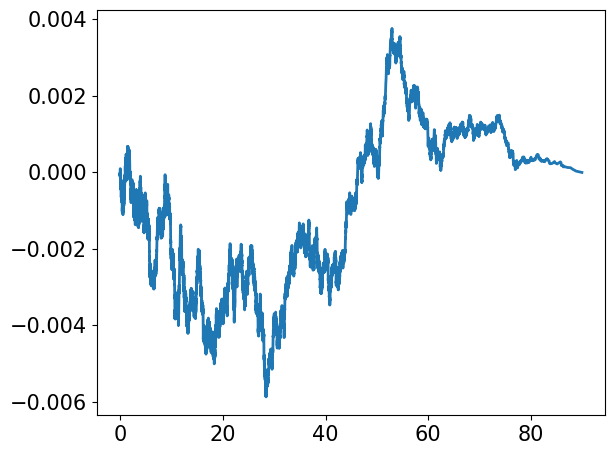

In [8]:
#plt.plot(*ecdf(measured_angles))
plt.plot(ecdf(measured_angles)[0],cos2_cdf(ecdf(measured_angles)[0])-ecdf(measured_angles)[1])

[0.02163967 1.9947711 ]
[[8.85326581e-05 1.05119133e-03]
 [1.05119133e-03 2.18242370e-02]]
107724
KstestResult(statistic=np.float64(0.9958230893882697), pvalue=np.float64(0.008353821223460622), statistic_location=np.float64(0.18796165180790694), statistic_sign=np.int8(1))


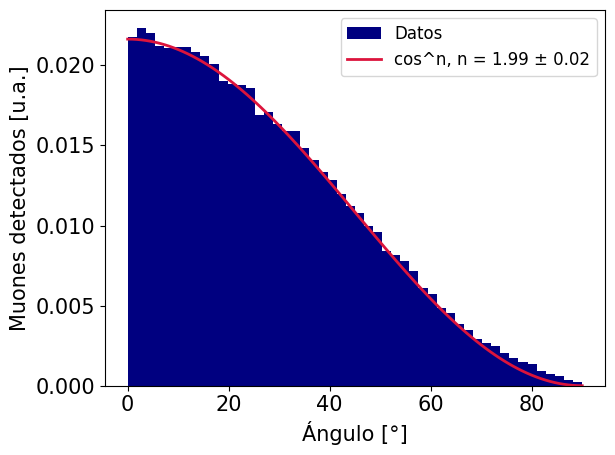

In [75]:
measured_angles = np.array([])
total_muons = []
for ang in [0,np.pi/8,np.pi/4,3*np.pi/8,np.pi/2,5*np.pi/8,3*np.pi/4,7*np.pi/8]:
    angles,muons = load_data(f'data/angulos_2r0/data_2_rot_{np.degrees(ang)}.csv')
    measured_angles = np.concat([measured_angles,angles])
    total_muons += muons

n,bins,_ = plt.hist(measured_angles,bins=50,density=True,color='navy',label='Datos')
x = np.linspace(0,90,100)
pars,cov = cf(cos_n,bins[:-1],n,p0=[4/np.pi,2])
#plt.plot(ecdf(measured_angles)[0],np.gradient(ecdf(measured_angles)[1],ecdf(measured_angles)[0]))
plt.plot(x,cos_n(x,*pars),c='crimson',label=f'cos^n, n = {np.round(pars[1],2)} \u00b1 {np.round(np.sqrt(cov[1,1]),2)}')
print(pars)
print(np.sqrt(cov))
#plt.plot(x,np.max(n)*np.cos(np.radians(x))**2,c='crimson',label='Distribución teórica')
plt.legend(fontsize=12)
plt.ylabel('Muones detectados [u.a.]')
plt.xlabel('Ángulo [°]')
plt.tight_layout()
print(len(measured_angles))
plt.savefig('plots/distribucion_2D.png')
print(kstest(measured_angles[1000],cos2_cdf))

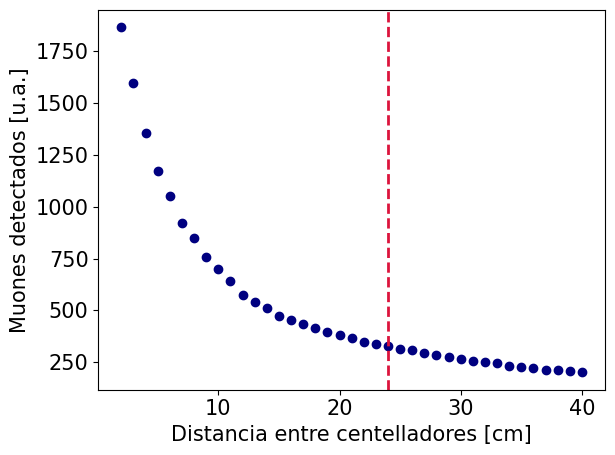

In [14]:
detecteds = np.loadtxt('data_2_rot_distancias.csv',delimiter=',')
plt.scatter(np.arange(2,40+1),detecteds,c='navy')
plt.axvline(24,color='crimson',ls='--')
plt.ylabel('Muones detectados [u.a.]')
plt.xlabel('Distancia entre centelladores [cm]')
plt.tight_layout()